In [ ]:
import os
import time
import json
import pickle
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

# Corrigindo dependências para evitar conflitos de versão
# Removemos versões fixas muito antigas para garantir compatibilidade com o Python 3.12 do Colab
!pip install -q google-genai datasets

from sklearn.base import clone
from google import genai
from google.genai import types

# Sklearn components
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    balanced_accuracy_score, confusion_matrix, classification_report
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer

# ── Download do Fake.Br ──
!if [ ! -d "/content/fake.br-corpus" ]; then git clone https://github.com/roneysco/Fake.br-Corpus.git /content/fake.br-corpus; else echo "✓ Fake.Br já baixado."; fi

# ── Download do Fakeddit ──
from datasets import load_dataset

print("Baixando Fakeddit do Hugging Face...")
fakeddit = load_dataset("ArkaMukherjee/Uni-Fakeddit-55k", split="train")
df_raw = fakeddit.to_pandas()

print("Formatando colunas do Fakeddit...")
records = []
for text in tqdm(df_raw['text']):
    text_match = re.search(r'\[TEXT\](.*?)(?:\[OBJECTS\]|\[LABEL\])', str(text), re.IGNORECASE)
    label_match = re.search(r'\[LABEL\](.*?)$', str(text), re.IGNORECASE)

    if text_match and label_match:
        clean_title = text_match.group(1).strip()
        label_str = label_match.group(1).strip().replace('.', '')
        try:
            records.append({"clean_title": clean_title, "2_way_label": int(label_str)})
        except ValueError:
            pass

df_fakeddit_processed = pd.DataFrame(records)

os.makedirs("/content/fakeddit", exist_ok=True)
FAKEDDIT_PATH = "/content/fakeddit/all_samples.tsv"
df_fakeddit_processed.to_csv(FAKEDDIT_PATH, sep="\t", index=False)

FAKEBR_PATH = "/content/fake.br-corpus/full_texts"

print(f"\n✓ Dados prontos! Fakeddit ({len(df_fakeddit_processed)} amostras) em {FAKEDDIT_PATH}")
print(f"✓ FakeBR em {FAKEBR_PATH}")

Cloning into '/content/fake.br-corpus'...
remote: Enumerating objects: 28763, done.
remote: Total 28763 (delta 0), reused 0 (delta 0), pack-reused 28763 (from 1)
Receiving objects: 100% (28763/28763), 37.10 MiB | 12.48 MiB/s, done.
Resolving deltas: 100% (14129/14129), done.
Updating files: 100% (21602/21602), done.
Baixando Fakeddit do Hugging Face...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/161 [00:00<?, ?B/s]

dataset_2way_output.txt: 0.00B [00:00, ?B/s]

dataset_3way_output.txt: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/110994 [00:00<?, ? examples/s]

Formatando colunas do Fakeddit...


100%|██████████| 110994/110994 [00:00<00:00, 200570.58it/s]



✓ Dados prontos! Fakeddit (110994 amostras) em /content/fakeddit/all_samples.tsv
✓ FakeBR em /content/fake.br-corpus/full_texts


## chamar cache

In [ ]:
from google.colab import drive
import os

# Monta o teu Google Drive
drive.mount('/content/drive')

# Cria a pasta do projeto no teu Drive (se ainda não existir)
PASTA_DRIVE = "/content/drive/MyDrive/embeddings_cache_cohere"
os.makedirs(PASTA_DRIVE, exist_ok=True)

print(f"✅ Drive conectado! Os ficheiros serão salvos em: {PASTA_DRIVE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive conectado! Os ficheiros serão salvos em: /content/drive/MyDrive/embeddings_cache_cohere


## configuração geral

In [ ]:
!pip install cohere

import cohere
from google.colab import userdata

# Carrega a chave do painel Secrets
chave_cohere = userdata.get('COHERE_API_KEY')

if chave_cohere:
    co = cohere.Client(chave_cohere)
    print("🚀 Cliente Cohere conectado com sucesso!")
else:
    print("❌ Erro: Chave COHERE_API_KEY não encontrada.")

# O modelo EXATO que você precisa para Inglês + Português
EMBEDDING_MODEL = 'embed-multilingual-v3.0'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.5/350.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 41.6 MB/s eta 0:00:00
🚀 Cliente Cohere conectado com sucesso!


## Load Data Set

In [ ]:
# 1. Instala a biblioteca do Cohere (caso ainda não tenha rodado)
!pip install cohere

from google.colab import userdata
import cohere
from pathlib import Path

# 2. Puxa a chave do Cohere (Lembre-se de criar no painel Secrets com o nome COHERE_API_KEY)
CHAVE_COHERE = userdata.get('COHERE_API_KEY')

# 3. Inicializa o cliente do Cohere
co = cohere.Client(CHAVE_COHERE)

# 4. Configurações Globais (Adaptadas para o Cohere)
EMBEDDING_MODEL = "embed-multilingual-v3.0"  # O modelo multilíngue do Cohere!
CACHE_DIR = Path("embeddings_cache_cohere")
CACHE_DIR.mkdir(exist_ok=True)

# 5. Teste rápido para confirmar que o COHERE está funcionando
test_response = co.embed(
    texts=["teste de conexão"],
    model=EMBEDDING_MODEL,
    input_type="classification"
)
print(f"✓ API do COHERE conectada com sucesso! | Dimensão do embedding: {len(test_response.embeddings[0])}")

✓ API do COHERE conectada com sucesso! | Dimensão do embedding: 1024


## embedding

In [ ]:
# ── CARREGAMENTO DOS DATASETS ──
from pathlib import Path
import pandas as pd

def load_fakeddit(path, max_samples=None):
    import pandas as pd

    print(f"Lendo Fakeddit limpo do Drive: {path}")
    # Lê usando tabulação porque é TSV
    df = pd.read_csv(path, sep="\t")

    # A limpeza vital: remove qualquer linha que não tenha texto ou rótulo
    df = df.dropna(subset=["clean_title", "2_way_label"])

    # Mantém só as colunas importantes e renomeia para o padrão do pipeline
    df = df[["clean_title", "2_way_label"]].copy()
    df = df.rename(columns={"clean_title": "text", "2_way_label": "label"})

    df["text"] = df["text"].astype(str).str.strip()
    df["label"] = pd.to_numeric(df["label"], errors="coerce")
    df = df.dropna(subset=["text", "label"])
    df = df[df["text"] != ""]

    print("\nFakeddit limpo carregado:")
    print(df["label"].value_counts().sort_index())

    # Balanceamento
    if max_samples is not None:
        per_class = max_samples // 2
        df = (
            df.sample(frac=1, random_state=42)
              .groupby("label")
              .head(per_class)
              .reset_index(drop=True)
        )

    return df

def load_fakebr(path: str, max_samples: int = None) -> pd.DataFrame:
    records = []
    for label_name, label_val in [("fake", 0), ("true", 1)]:
        folder = Path(path) / label_name
        if not folder.exists():
            raise FileNotFoundError(f"Pasta não encontrada: {folder}")
        for txt_file in folder.glob("*.txt"):
            text = txt_file.read_text(encoding="utf-8", errors="ignore").strip()
            if text:
                records.append({"text": text, "label": label_val})

    df = pd.DataFrame(records)

    if max_samples:
        per_class = max_samples // 2
        # Embaralha todas as linhas e pega as primeiras 'per_class' de cada rótulo
        df = (
            df.sample(frac=1, random_state=42)
              .groupby("label")
              .head(per_class)
              .reset_index(drop=True)
        )
    print(f"[Fake.Br] {len(df)} amostras")
    print(df["label"].value_counts().to_string(), "\n")
    return df

In [ ]:
import os
import time
import pickle
import numpy as np
from tqdm import tqdm
from pathlib import Path

def get_embedding(text: str, task_type: str = "CLASSIFICATION") -> list:
    """Retorna o embedding de um texto via Gemini."""
    result = genai.embed_content(
        model=EMBEDDING_MODEL,
        content=text,
        task_type=task_type
    )
    return result["embedding"]

import os
import time
import pickle
import numpy as np
from tqdm import tqdm
from pathlib import Path

def extract_embeddings_batch_cohere(
    texts: list,
    cache_file: Path
) -> np.ndarray:
    """Extrai embeddings usando Cohere com checkpointing e controle de limites."""

    # 1. Se o arquivo FINAL já existe, pula e carrega
    if cache_file.exists():
        print(f"  → Cache final encontrado: {cache_file}. Carregando...")
        with open(cache_file, "rb") as f:
            return pickle.load(f)

    # 2. Configura o arquivo parcial (O "Salva-Vidas")
    partial_file = cache_file.with_suffix('.partial.pkl')
    embeddings = []
    start_idx = 0

    if partial_file.exists():
        with open(partial_file, "rb") as f:
            embeddings = pickle.load(f)
        start_idx = len(embeddings)
        print(f"  ♻️ Progresso salvo encontrado! Retomando do texto {start_idx} de {len(texts)}...")

    # O Cohere aceita lotes maiores. 50 é um tamanho excelente e seguro.
    NOVO_BATCH_SIZE = 50

    total_batches = (len(texts) + NOVO_BATCH_SIZE - 1) // NOVO_BATCH_SIZE
    initial_batch = start_idx // NOVO_BATCH_SIZE

    for i in tqdm(range(start_idx, len(texts), NOVO_BATCH_SIZE),
                  desc="Extraindo embeddings (Cohere)",
                  initial=initial_batch,
                  total=total_batches):

        batch = texts[i: i + NOVO_BATCH_SIZE]
        sucesso = False

        while not sucesso:
            try:
                # Chamada oficial da API do Cohere
                response = co.embed(
                    texts=[str(text)[:2000] for text in batch],
                    model=EMBEDDING_MODEL,
                    input_type='classification' # Diz ao modelo que é para ML/Classificação
                )

                # Extrai os vetores da resposta
                for emb in response.embeddings:
                    embeddings.append(emb)

                sucesso = True

            except Exception as e:
                erro_msg = str(e).lower()

                # Erro 429: Limite por minuto excedido
                if "429" in erro_msg or "too many requests" in erro_msg or "rate limit" in erro_msg:
                    print(f"\n  ⏳ Limite da API atingido. Pausando por 60 segundos...")
                    time.sleep(60)

                # Erro 401/403: Chave bloqueada ou inválida
                elif "401" in erro_msg or "403" in erro_msg or "unauthorized" in erro_msg:
                    raise RuntimeError("❌ Sua chave do Cohere é inválida ou foi bloqueada.")

                # Outros erros
                else:
                    print(f"\n  ⚠ Erro fatal no lote {i}: {erro_msg}. Preenchendo com zeros.")
                    # O modelo v3.0 do Cohere tem 1024 dimensões (diferente das 3072 do Gemini)
                    for _ in range(len(batch)):
                        embeddings.append([0.0] * 1024)
                    sucesso = True

        # 3. SALVAMENTO PARCIAL NO HD
        cache_file.parent.mkdir(parents=True, exist_ok=True)
        with open(partial_file, "wb") as f:
            pickle.dump(embeddings, f)

        # Pausa leve de 12 segundos entre lotes para não estressar a cota gratuita
        time.sleep(12.0)

    # 4. Finalização
    result = np.array(embeddings, dtype=np.float32)

    with open(cache_file, "wb") as f:
        pickle.dump(result, f)

    if partial_file.exists():
        os.remove(partial_file)

    print(f"  → {len(texts)} embeddings extraídos com sucesso. Shape: {result.shape}")
    return result

## classificadores

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV

def build_optimized_classifiers():
    """
    Constrói classificadores encapsulados em GridSearchCV para encontrar
    os melhores hiperparâmetros automaticamente.
    """
    classifiers = {}

    # 1. Regressão Logística Otimizada
    logreg_pipe = make_pipeline(Normalizer(norm="l2"), LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42))
    logreg_params = {'logisticregression__C': [0.01, 0.1, 1.0, 10.0, 100.0]}
    classifiers["LogisticRegression_Opt"] = GridSearchCV(logreg_pipe, logreg_params, cv=3, scoring='f1_macro', n_jobs=-1)

    # 2. Linear SVC Otimizado
    svc_pipe = make_pipeline(Normalizer(norm="l2"), LinearSVC(class_weight="balanced", max_iter=5000, random_state=42))
    svc_params = {'linearsvc__C': [0.01, 0.1, 1.0, 10.0]}
    classifiers["LinearSVC_Opt"] = GridSearchCV(svc_pipe, svc_params, cv=3, scoring='f1_macro', n_jobs=-1)

    # 3. Random Forest Otimizada
    rf = RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1)
    rf_params = {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    }
    classifiers["RandomForest_Opt"] = GridSearchCV(rf, rf_params, cv=3, scoring='f1_macro')

    return classifiers

## avaliando

In [ ]:

import numpy as np
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import matthews_corrcoef

def evaluate_classifier(clf, X, y, cv=5):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    scoring = {
        "accuracy": "accuracy",
        "precision_macro": "precision_macro",
        "recall_macro": "recall_macro",
        "f1_macro": "f1_macro",
        "balanced_accuracy": "balanced_accuracy",
    }

    # adiciona ROC-AUC e Average Precision só se fizer sentido
    if hasattr(clf, "predict_proba") or hasattr(clf, "decision_function"):
        try:
            scoring["roc_auc"] = "roc_auc"
        except:
            pass

    if hasattr(clf, "predict_proba"):
        try:
            scoring["average_precision"] = "average_precision"
        except:
            pass

    cv_results = cross_validate(
        clf,
        X,
        y,
        cv=skf,
        scoring=scoring,
        n_jobs=-1
    )

    mcc_scores = []
    for train_idx, test_idx in skf.split(X, y):
        clf_copy = clone(clf)
        clf_copy.fit(X[train_idx], y[train_idx])
        y_pred = clf_copy.predict(X[test_idx])
        mcc_scores.append(matthews_corrcoef(y[test_idx], y_pred))

    summary = {}
    for k, v in cv_results.items():
        if k.startswith("test_"):
            metric = k[5:]
            summary[metric] = {
                "mean": float(np.mean(v)),
                "std": float(np.std(v))
            }

    summary["mcc"] = {
        "mean": float(np.mean(mcc_scores)),
        "std": float(np.std(mcc_scores))
    }

    return summary


def print_results(results: dict):
    """Imprime os resultados de forma legível."""
    for dataset_name, classifiers in results.items():
        print(f"\n{'='*60}")
        print(f"  Dataset: {dataset_name}")
        print(f"{'='*60}")
        for clf_name, metrics in classifiers.items():
            print(f"\n  Classificador: {clf_name}")
            print(f"  {'Métrica':<25} {'Média':>8}  {'±':>2}  {'Desvio':>8}")
            print(f"  {'-'*48}")
            for metric, vals in metrics.items():
                print(f"  {metric:<25} {vals['mean']:>8.4f}  ±  {vals['std']:>8.4f}")


def results_to_dataframe(results: dict) -> pd.DataFrame:
    """Converte resultados em DataFrame para exportar/visualizar."""
    rows = []
    for dataset_name, classifiers in results.items():
        for clf_name, metrics in classifiers.items():
            for metric, vals in metrics.items():
                rows.append({
                    "dataset":    dataset_name,
                    "classifier": clf_name,
                    "metric":     metric,
                    "mean":       vals["mean"],
                    "std":        vals["std"],
                })
    return pd.DataFrame(rows)


## visualizando

In [ ]:
def plot_metrics_comparison(df_results: pd.DataFrame, save_path: str = None):
    """Gráfico de barras comparando datasets e classificadores por métrica."""
    key_metrics = ["f1_macro", "accuracy", "roc_auc", "balanced_accuracy", "mcc"]
    df_plot = df_results[df_results["metric"].isin(key_metrics)]

    g = sns.FacetGrid(df_plot, col="metric", col_wrap=3, height=4, sharey=False)
    g.map_dataframe(
        sns.barplot, x="classifier", y="mean", hue="dataset",
        palette="Set2", capsize=0.1,
        errorbar=None
    )
    g.add_legend()
    g.set_axis_labels("Classificador", "Score")
    g.set_titles(col_template="{col_name}")
    plt.suptitle("Experimento 1 — Comparação de Métricas", y=1.02, fontsize=13)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()


def plot_embedding_space(
    X: np.ndarray, y: np.ndarray,
    title: str, method: str = "pca",
    save_path: str = None
):
    """
    Visualiza o espaço de embeddings via PCA ou t-SNE.
    method: 'pca' (rápido) ou 'tsne' (melhor separação visual)
    """
    print(f"  Reduzindo dimensionalidade com {method.upper()}...")

    if method == "tsne":
        reducer = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=500)
    else:
        reducer = PCA(n_components=2, random_state=42)

    X_2d = reducer.fit_transform(X)

    fig, ax = plt.subplots(figsize=(7, 5))
    colors = {0: "#e74c3c", 1: "#2ecc71"}
    labels_map = {0: "Fake", 1: "Real"}

    for lbl in [0, 1]:
        mask = y == lbl
        ax.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            c=colors[lbl], label=labels_map[lbl],
            alpha=0.5, s=15, edgecolors="none"
        )

    ax.set_title(f"{title} — {method.upper()}")
    ax.set_xlabel("Componente 1")
    ax.set_ylabel("Componente 2")
    ax.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()


def plot_confusion_matrix(clf, X: np.ndarray, y: np.ndarray, title: str):
    """Matriz de confusão com o classificador já treinado."""
    from sklearn.model_selection import cross_val_predict
    y_pred = cross_val_predict(clf, X, y, cv=5)
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Fake", "Real"],
        yticklabels=["Fake", "Real"]
    )
    plt.title(f"Matriz de Confusão — {title}")
    plt.ylabel("Real")
    plt.xlabel("Previsto")
    plt.tight_layout()
    plt.show()


## otimizador

In [ ]:
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

def optimize_embedding_dimensions(X, y, dataset_name, clf):
    """
    Testa diferentes números de componentes do PCA e plota a curva de F1-Macro
    para encontrar a dimensionalidade ótima.
    """
    print(f"\n[Otimização PCA] Buscando dimensões ótimas para {dataset_name}...")

    # Lista de dimensões para testar (não pode ser maior que o número de amostras ou dimensões originais)
    max_dim = min(X.shape[0], X.shape[1])
    dimensions_to_test = [10, 50, 100, 250, 500, 750, 1000]
    dimensions_to_test = [d for d in dimensions_to_test if d <= max_dim]

    scores = []

    for n_dim in dimensions_to_test:
        print(f"  Testando {n_dim} dimensões...")
        pca = PCA(n_components=n_dim, random_state=42)
        X_reduced = pca.fit_transform(X)

        # Avalia usando F1-Macro
        score = cross_val_score(clf, X_reduced, y, cv=5, scoring='f1_macro', n_jobs=-1).mean()
        scores.append(score)

    # Plotando a curva
    plt.figure(figsize=(8, 5))
    plt.plot(dimensions_to_test, scores, marker='o', linestyle='-', color='b')
    plt.title(f'Otimização de Dimensões (PCA) - {dataset_name}')
    plt.xlabel('Número de Componentes (Dimensões)')
    plt.ylabel('F1-Macro Score (Validação Cruzada)')
    plt.grid(True)
    plt.savefig(f"pca_optimization_{dataset_name.split()[0]}.png")
    plt.show()

    # Retorna o melhor número de componentes
    best_dim = dimensions_to_test[np.argmax(scores)]
    print(f"✓ Melhor número de dimensões para {dataset_name}: {best_dim} (F1: {max(scores):.4f})")

    return best_dim

## pipeline principal

In [ ]:
def run_experiment_1(
    fakeddit_path: str,
    fakebr_path: str,
    max_samples: int = 2000,   # None para usar tudo
    use_tsne: bool = False      # True = t-SNE (lento mas bonito)
):
    """
    Executa o Experimento 1 completo:
      1. Carrega datasets
      2. Extrai embeddings textuais do Gemini
      3. Treina e avalia classificadores (5-fold CV)
      4. Gera tabelas e gráficos
    """

    print("\n" + "="*60)
    print("  EXPERIMENTO 1 — Gemini Text Embedding")
    print("  Fakeddit (EN) vs Fake.Br (PT)")
    print("="*60 + "\n")

    # ── 7.1 Carregamento ──────────────────────────────────────────
    df_fakeddit = load_fakeddit(fakeddit_path, max_samples=max_samples)
    df_fakebr   = load_fakebr(fakebr_path,   max_samples=max_samples)

    datasets = {
        "Fakeddit (EN)": df_fakeddit,
        "Fake.Br (PT)":  df_fakebr,
    }

    # ── 7.2 Extração de embeddings ────────────────────────────────
    embeddings_map = {}
    for name, df in datasets.items():
        safe_name = name.replace(" ", "_").replace("(", "").replace(")", "")
        cache_file = Path(f"/content/drive/MyDrive/embeddings_cache_cohere/embeddings_{safe_name}_cohere.pkl")
        print(f"\n[Embeddings] {name}")
        X = extract_embeddings_batch_cohere(df["text"].tolist(), cache_file)
        y = df["label"].values
        embeddings_map[name] = (X, y)

# ── 7.3 Classificação e avaliação (AGORA COM OTIMIZAÇÃO) ────────────────────────────

    # 1. Chama os novos classificadores com GridSearch (adicione a função build_optimized_classifiers antes no arquivo)
    classifiers = build_optimized_classifiers()
    all_results = {}

    for name, (X, y) in embeddings_map.items():
        print(f"\n[Otimização PCA] {name}")

        # 2. Descobrir a melhor dimensão usando um classificador rápido (LogReg)
        base_clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

        # Adicione a função optimize_embedding_dimensions antes no arquivo
        best_dim = optimize_embedding_dimensions(X, y, name, base_clf)

        # 3. Aplicar o PCA com a melhor dimensão encontrada (aqui cortamos o ruído)
        pca = PCA(n_components=best_dim, random_state=42)
        X_optimized = pca.fit_transform(X)

        print(f"\n[Avaliação Otimizada] {name} (com {best_dim} dimensões)")
        all_results[name] = {}

        for clf_name, clf in classifiers.items():
            print(f"  → {clf_name} (Testando hiperparâmetros...)")

            # 4. Avalia usando o X_optimized (reduzido) em vez do X original
            metrics = evaluate_classifier(clf, X_optimized, y, cv=5)
            all_results[name][clf_name] = metrics

    # ── 7.4 Exibição dos resultados ───────────────────────────────
    print_results(all_results)

    df_results = results_to_dataframe(all_results)
    df_results.to_csv("resultados_experimento1.csv", index=False)
    print("\n✓ Resultados salvos em resultados_experimento1.csv")

    # ── 7.5 Visualizações ─────────────────────────────────────────
    print("\n[Gráficos] Métricas comparativas")
    plot_metrics_comparison(df_results, save_path="metricas_exp1.png")

    viz_method = "tsne" if use_tsne else "pca"
    for name, (X, y) in embeddings_map.items():
        print(f"\n[Gráficos] Espaço de embeddings — {name}")
        plot_embedding_space(X, y, title=name, method=viz_method,
                             save_path=f"embeddings_{name.split()[0]}.png")

    # Matriz de confusão do melhor classificador
    for name, (X, y) in embeddings_map.items():
        clf = LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs", random_state=42)
        plot_confusion_matrix(clf, X, y, title=f"LogReg — {name}")

    print("\n✓ Experimento 1 concluído!")
    return all_results, df_results



## Deletar cache

In [ ]:
"""import shutil

# Isso vai deletar a pasta de cache inteira e tudo que tem dentro dela
shutil.rmtree("embeddings_cache", ignore_errors=True)
print("🗑️ Cache deletado com sucesso! Pode rodar a extração novamente.")"""

'import shutil\n\n# Isso vai deletar a pasta de cache inteira e tudo que tem dentro dela\nshutil.rmtree("embeddings_cache", ignore_errors=True)\nprint("🗑️ Cache deletado com sucesso! Pode rodar a extração novamente.")'

## salvar no drive fakedit

In [ ]:
"""from google.colab import drive
import shutil

# 1. Isso vai abrir uma janelinha pedindo permissão para acessar seu Google Drive
drive.mount('/content/drive')

# 2. Isso vai copiar a pasta de cache inteira para o seu Drive!
shutil.copytree("embeddings_cache", "/content/drive/MyDrive/embeddings_cache", dirs_exist_ok=True)

print("✅ Arquivo salvo com segurança no seu Google Drive! Agora sim você pode fechar a aba.")"""

'from google.colab import drive\nimport shutil\n\n# 1. Isso vai abrir uma janelinha pedindo permissão para acessar seu Google Drive\ndrive.mount(\'/content/drive\')\n\n# 2. Isso vai copiar a pasta de cache inteira para o seu Drive!\nshutil.copytree("embeddings_cache", "/content/drive/MyDrive/embeddings_cache", dirs_exist_ok=True)\n\nprint("✅ Arquivo salvo com segurança no seu Google Drive! Agora sim você pode fechar a aba.")'

## execução


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Verificando dataset Fakeddit...
['author', 'clean_title', 'created_utc', 'domain', 'hasImage', 'id', 'image_url', 'linked_submission_id', 'num_comments', 'score', 'subreddit', 'title', 'upvote_ratio', '2_way_label', '3_way_label', '6_way_label']
2_way_label
0    341919
1    222081
Name: count, dtype: int64
           author                                        clean_title  \
0     Alexithymia  my walgreens offbrand mucinex was engraved wit...   
1        VIDCAs17                this concerned sink with a tiny hat   
2  prometheus1123      hackers leak emails from uae ambassador to us   
3             NaN                           puppy taking in the view   
4       3rikR3ith               i found a face in my sheet music too   

    created_utc         domain  hasImage      id  \
0  1.551641e+09    i.imgur.com      True  awxhir   
1  1.534727e+09      i.r

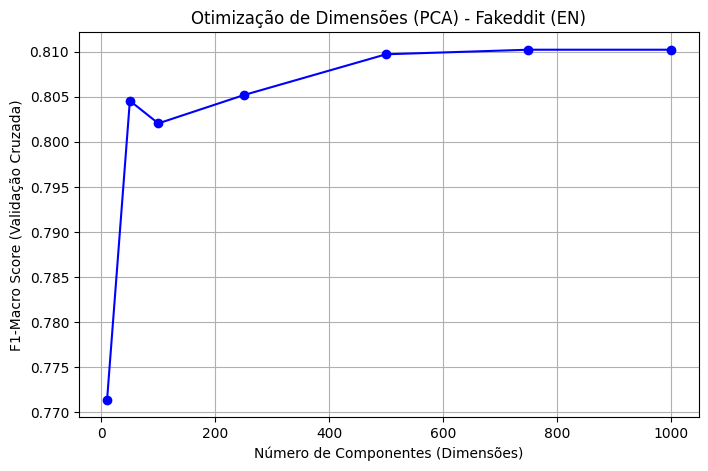

✓ Melhor número de dimensões para Fakeddit (EN): 750 (F1: 0.8102)

[Avaliação Otimizada] Fakeddit (EN) (com 750 dimensões)
  → LogisticRegression_Opt (Testando hiperparâmetros...)
  → LinearSVC_Opt (Testando hiperparâmetros...)
  → RandomForest_Opt (Testando hiperparâmetros...)

[Otimização PCA] Fake.Br (PT)

[Otimização PCA] Buscando dimensões ótimas para Fake.Br (PT)...
  Testando 10 dimensões...
  Testando 50 dimensões...
  Testando 100 dimensões...
  Testando 250 dimensões...
  Testando 500 dimensões...
  Testando 750 dimensões...
  Testando 1000 dimensões...


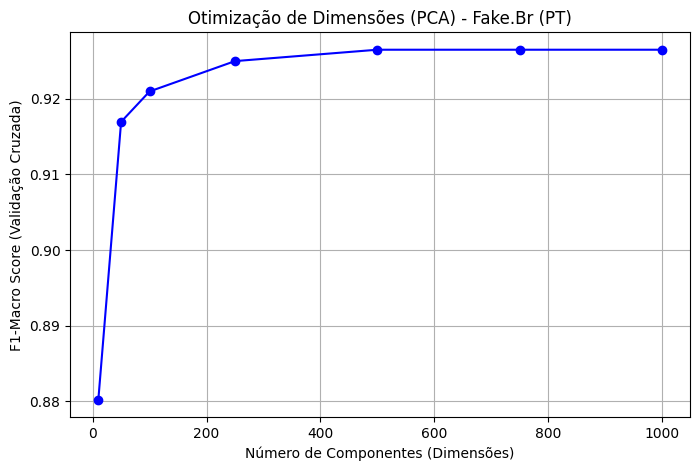

✓ Melhor número de dimensões para Fake.Br (PT): 500 (F1: 0.9264)

[Avaliação Otimizada] Fake.Br (PT) (com 500 dimensões)
  → LogisticRegression_Opt (Testando hiperparâmetros...)
  → LinearSVC_Opt (Testando hiperparâmetros...)
  → RandomForest_Opt (Testando hiperparâmetros...)

  Dataset: Fakeddit (EN)

  Classificador: LogisticRegression_Opt
  Métrica                      Média   ±    Desvio
  ------------------------------------------------
  accuracy                    0.8080  ±    0.0234
  precision_macro             0.8097  ±    0.0242
  recall_macro                0.8080  ±    0.0234
  f1_macro                    0.8078  ±    0.0233
  balanced_accuracy           0.8080  ±    0.0234
  roc_auc                     0.8876  ±    0.0180
  average_precision           0.8713  ±    0.0186
  mcc                         0.6177  ±    0.0476

  Classificador: LinearSVC_Opt
  Métrica                      Média   ±    Desvio
  ------------------------------------------------
  accuracy          

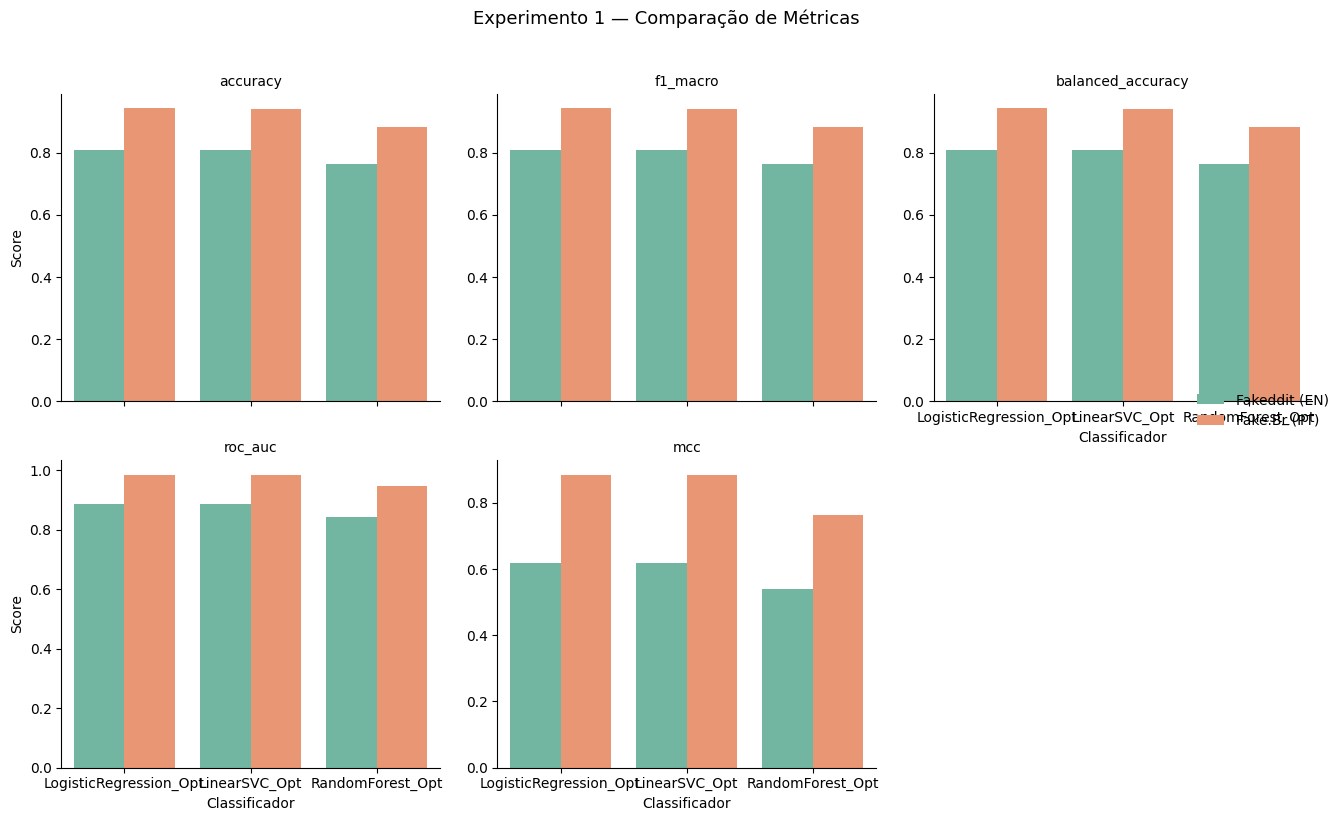


[Gráficos] Espaço de embeddings — Fakeddit (EN)
  Reduzindo dimensionalidade com PCA...


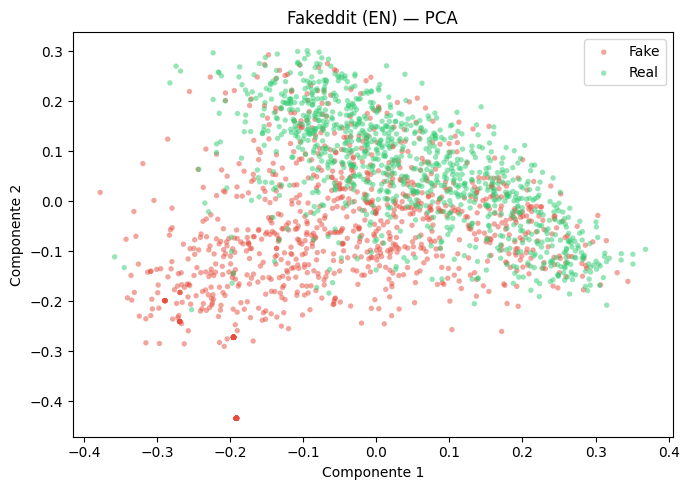


[Gráficos] Espaço de embeddings — Fake.Br (PT)
  Reduzindo dimensionalidade com PCA...


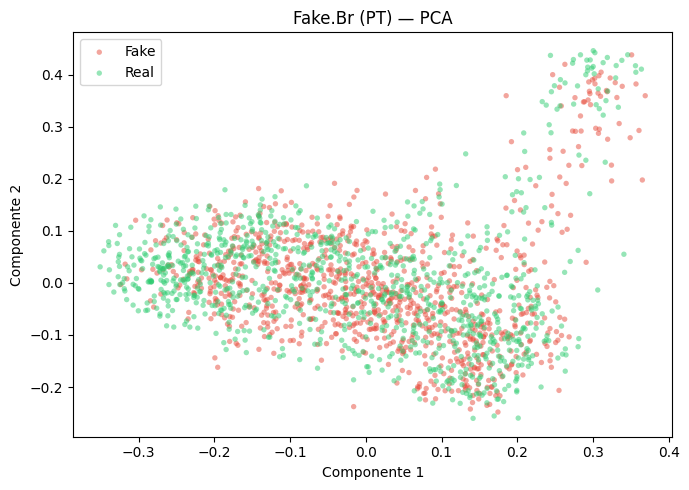

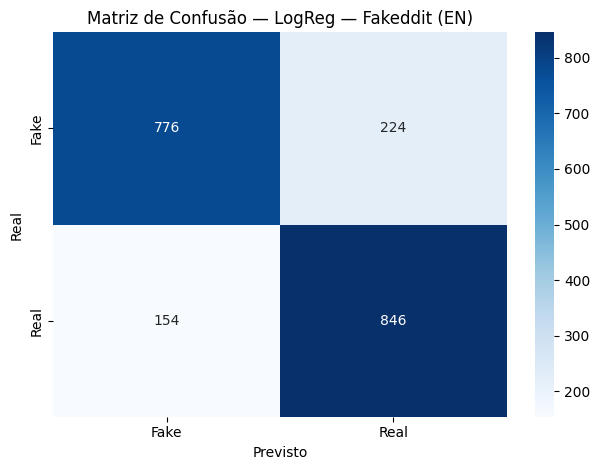

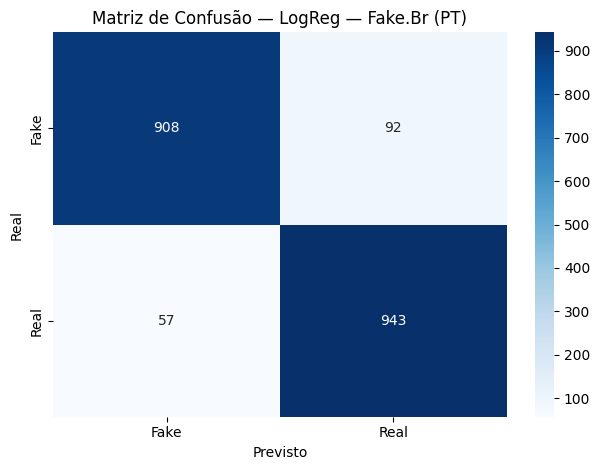


✓ Experimento 1 concluído!


In [ ]:
from google.colab import drive
from pathlib import Path
import pandas as pd

if __name__ == "__main__":
    # ============================================================
    # 1. CONECTAR O DRIVE E CRIAR A PASTA DO COHERE
    # ============================================================
    drive.mount('/content/drive')
    PASTA_DRIVE = Path("/content/drive/MyDrive/embeddings_cache_cohere")
    PASTA_DRIVE.mkdir(parents=True, exist_ok=True)

    # ============================================================
    # 2. CAMINHOS DOS DADOS ORIGINAIS
    # ============================================================
    FAKEDDIT_PATH = "/content/drive/MyDrive/fakeddit/multimodal_train.tsv"
    FAKEBR_PATH = "/content/fake.br-corpus/full_texts"

    # Verificação rápida do Fakeddit
    print("📂 Verificando dataset Fakeddit...")
    df = pd.read_csv(FAKEDDIT_PATH, sep="\t")
    print(df.columns.tolist())
    print(df["2_way_label"].value_counts().sort_index())
    print(df.head())

    # ============================================================
    # 3. EXECUÇÃO DO EXPERIMENTO
    # ============================================================
    print("\n🚀 Iniciando Pipeline Completo (Cohere)...")

    results, df_final = run_experiment_1(
        fakeddit_path=FAKEDDIT_PATH,
        fakebr_path=FAKEBR_PATH,
        max_samples=2000,
        use_tsne=False,
    )

## reset cache

In [ ]:
'''import os

cache_files = [
    "embeddings_cache/embeddings_Fakeddit_EN.pkl",
    "embeddings_cache/embeddings_Fake.Br_PT.pkl",
]

for f in cache_files:
    if os.path.exists(f):
        os.remove(f)
        print("Removido:", f)
    else:
        print("Não encontrado:", f)'''

'import os\n\ncache_files = [\n    "embeddings_cache/embeddings_Fakeddit_EN.pkl",\n    "embeddings_cache/embeddings_Fake.Br_PT.pkl",\n]\n\nfor f in cache_files:\n    if os.path.exists(f):\n        os.remove(f)\n        print("Removido:", f)\n    else:\n        print("Não encontrado:", f)'

## nova analise

In [ ]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import matthews_corrcoef
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

In [ ]:
def evaluate_text_classifier(clf, X_text, y, cv=5):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    scoring = {
        "accuracy": "accuracy",
        "precision_macro": "precision_macro",
        "recall_macro": "recall_macro",
        "f1_macro": "f1_macro",
        "balanced_accuracy": "balanced_accuracy",
        "roc_auc": "roc_auc",
    }

    cv_results = cross_validate(
        clf,
        X_text,
        y,
        cv=skf,
        scoring=scoring,
        n_jobs=-1
    )

    mcc_scores = []
    for train_idx, test_idx in skf.split(X_text, y):
        clf_copy = clone(clf)
        X_train = X_text.iloc[train_idx]
        X_test = X_text.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        clf_copy.fit(X_train, y_train)
        y_pred = clf_copy.predict(X_test)
        mcc_scores.append(matthews_corrcoef(y_test, y_pred))

    summary = {}
    for k, v in cv_results.items():
        if k.startswith("test_"):
            metric = k[5:]
            summary[metric] = {
                "mean": float(np.mean(v)),
                "std": float(np.std(v))
            }

    summary["mcc"] = {
        "mean": float(np.mean(mcc_scores)),
        "std": float(np.std(mcc_scores))
    }

    return summary

In [ ]:
def build_tfidf_classifiers():
    return {
        "TFIDF+LinearSVC": make_pipeline(
            TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True
            ),
            LinearSVC(
                C=1.0,
                class_weight="balanced",
                max_iter=5000,
                random_state=42
            )
        ),
        "TFIDF+LogReg": make_pipeline(
            TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True
            ),
            LogisticRegression(
                C=1.0,
                class_weight="balanced",
                max_iter=5000,
                random_state=42
            )
        )
    }

In [ ]:
def run_tfidf_baseline(fakeddit_path, fakebr_path, max_samples=2000):
    df_fakeddit = load_fakeddit(fakeddit_path, max_samples=max_samples)
    df_fakebr = load_fakebr(fakebr_path, max_samples=max_samples)

    datasets = {
        "Fakeddit (EN)": df_fakeddit,
        "Fake.Br (PT)": df_fakebr
    }

    classifiers = build_tfidf_classifiers()
    all_results = {}

    for dataset_name, df in datasets.items():
        print("\n" + "=" * 60)
        print(f"Dataset: {dataset_name}")
        print("=" * 60)

        X_text = df["text"]
        y = df["label"]

        all_results[dataset_name] = {}

        for clf_name, clf in classifiers.items():
            print(f"\nClassificador: {clf_name}")
            result = evaluate_text_classifier(clf, X_text, y, cv=5)
            all_results[dataset_name][clf_name] = result

            print(f"{'Métrica':25s} {'Média':>8s} {'±':>3s} {'Desvio':>9s}")
            print("-" * 50)
            for metric, values in result.items():
                print(f"{metric:25s} {values['mean']:8.4f} {'±':>3s} {values['std']:9.4f}")

    return all_results

In [ ]:
tfidf_results = run_tfidf_baseline(
    fakeddit_path=FAKEDDIT_PATH,
    fakebr_path=FAKEBR_PATH,
    max_samples=2000
)

Lendo Fakeddit limpo do Drive: /content/drive/MyDrive/fakeddit/multimodal_train.tsv

Fakeddit limpo carregado:
label
0    341919
1    222081
Name: count, dtype: int64
[Fake.Br] 2000 amostras
label
0    1000
1    1000 


Dataset: Fakeddit (EN)

Classificador: TFIDF+LinearSVC
Métrica                      Média   ±    Desvio
--------------------------------------------------
accuracy                    0.7160   ±    0.0044
precision_macro             0.7165   ±    0.0039
recall_macro                0.7160   ±    0.0044
f1_macro                    0.7158   ±    0.0045
balanced_accuracy           0.7160   ±    0.0044
roc_auc                     0.7836   ±    0.0109
mcc                         0.4325   ±    0.0083

Classificador: TFIDF+LogReg
Métrica                      Média   ±    Desvio
--------------------------------------------------
accuracy                    0.7285   ±    0.0082
precision_macro             0.7288   ±    0.0082
recall_macro                0.7285   ±    0.0082
f1_mac